# Вопрос 09. Метрические и нормированные пространства. Гильбертовы пространства. Теорема Рисса — численные примеры

Файл ведётся в формате jupytext (percent). Парный `.ipynb` получается
командой `make questions/09-hilbert-riesz/examples.ipynb`; в git идёт **этот**
файл, ноутбук — производный артефакт.

**Сквозной пример один** и тот же, что в конспекте: сигнал со скачком и прибор,
измеряющий контраст.

* сигнал $u(t) = \operatorname{sign}(t - 1/2)$ на $[0,1]$ — единичная
  амплитуда, скачок посередине; в $L_2(0,1)$ лежит, в $C[0,1]$ нет;
* непрерывные «пандусы» $u_n(t) = \max\{-1, \min\{1, 2n(t-1/2)\}\}$ —
  записи с переключением длительности $1/n$;
* прибор — функционал контраста
  $f(x) = \int_0^{1/2} x\,dt - \int_{1/2}^1 x\,dt$.

Четыре примера, каждый отвечает на вопрос из `theory.md`; **предсказание
формулируется до прогона** и остаётся в тексте, даже если не сбылось.

| № | Вопрос из конспекта | Предсказание |
|---|---|---|
| 1 | зависит ли полнота от метрики | $\rho_2(u_n,u) = 1/\sqrt{3n}$, $\rho_1(u_n,u) = 1/(2n)$; в равномерной метрике последовательность не фундаментальна |
| 2 | какая норма $L_p$ порождена скалярным произведением | дефект тождества параллелограмма равен $2 - 4\cdot2^{-2/p}$ и обращается в ноль только при $p=2$ |
| 3 | что даёт теорема о проекции и что она не даёт | математически одночленный и ортогональный путь совпадают, численно расходятся начиная с $n$ порядка десяти |
| 4 | как выглядит представитель функционала | $\lVert y_n\rVert$ растёт снизу к $\lVert f\rVert = 1$; у неограниченного функционала частичные нормы растут как $n^{3/2}$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import legendre as npleg

SEED = 20260930

# Randomness is used only for spot-checks of identities that must hold for EVERY
# element (Riesz representation, parallelogram law): one hand-picked pair proves
# far less than a sweep over random ones.
rng = np.random.default_rng(SEED)

FIGDIR = "figures"

# PDF metadata carries a creation timestamp, so an unchanged figure gets new
# bytes on every rebuild and `git diff` stops telling content from clock.
SAVE_KW = {"metadata": {"CreationDate": None}}

# Golden pins: seed AND expected output are frozen constants. Without the second
# half, "reproducibility" only checks a run against itself, which proves nothing.
# A mismatch aborts the notebook build, so the pin acts as a gate.
#
# Tolerance is set per pin: quantities available in closed form get machine
# level; quantities that depend on floating-point cancellation (the monomial
# route past n = 12) get a tolerance reflecting the actual spread.
GOLDEN = {
    # Closed form, derived in theory.md and cross-checked against exact quadrature.
    "rho2_ramp_100": (0.05773502691896257, 1e-12),
    "rho1_ramp_100": (0.005, 1e-12),
    "sup_gap_ramp": (0.5, 1e-12),
    "defect_p1": (1.0, 1e-12),
    "defect_p2": (0.0, 1e-12),
    "defect_p4": (-0.8284271247461903, 1e-12),
    "legendre_c1": (0.8660254037844387, 1e-12),
    "legendre_c3": (-0.3307189138830738, 1e-12),
    # 63/256 exactly: the residual after nine Legendre terms is dyadic.
    "resid_legendre_9": (0.24609375, 1e-12),
    "haar_resid": (0.0, 1e-12),
    "norm_f": (1.0, 1e-12),
    # Sums of forty closed-form terms: deterministic, but the value has no short
    # closed form, so it is copied from a run rather than written by hand.
    "resid_legendre_40": (0.12537068761957862, 1e-12),
    "slope_legendre_resid": (-0.4504852028275246, 1e-9),
    "slope_unbounded_near": (1.4793384337184585, 1e-9),
    "slope_unbounded_far": (1.4984591793836657, 1e-9),
    # Double-precision artefacts, and that IS the subject of example 3: both
    # quantities come out of a nearly singular solve, so their low digits depend
    # on the BLAS in use. The tolerance says how much of the value is meaningful.
    "cond_hilbert_10": (522772452573708.7, 0.5),
    "resid_monomial_18": (0.20863841512657166, 1e-2),
}



def check_golden(name, value):
    want, tol = GOLDEN[name]
    denom = max(abs(want), 1e-300)
    err = abs(value - want) / denom if want != 0 else abs(value)
    print(f"  пин {name}: получено {value:.12g}, ожидалось {want:.12g} (допуск {tol:g})")
    assert err <= tol, f"golden-пин {name} не сошёлся: {value} vs {want}"

## Сквозной пример: сигнал, пандусы, функционал

Всё, что ниже, точное: сигнал кусочно постоянен, пандусы кусочно линейны,
базисные функции — многочлены, поэтому все интегралы берутся в замкнутом виде,
а квадратуры используются только как независимая проверка.

In [2]:
def signal(t):
    """u(t) = sign(t - 1/2): the step signal. Value at t = 1/2 is irrelevant (measure zero)."""
    return np.sign(np.asarray(t, dtype=float) - 0.5)


def ramp(t, n):
    """u_n: continuous approximation of the step, switching over an interval of length 1/n."""
    return np.clip(2.0 * n * (np.asarray(t, dtype=float) - 0.5), -1.0, 1.0)


def contrast(values_left_right):
    """The functional f: difference of the means over the two halves.

    Takes the pair of exact half-integrals, so callers stay responsible for
    integrating exactly rather than hiding a quadrature here.
    """
    left, right = values_left_right
    return left - right


# Midpoint grid on NCELL equal cells. NCELL is chosen so that every breakpoint
# used below — 1/2, the 1/100 boundaries of the random step functions, the dyadic
# 1/16 boundaries of the Haar system — falls on a CELL BOUNDARY. For a function
# that is constant inside each cell the midpoint rule is then exact, not
# approximate, and no midpoint ever lands on 1/2, where sign() is undefined.
NCELL = 200_000
assert NCELL % 200 == 0 and NCELL % 16 == 0
GRID = (np.arange(NCELL) + 0.5) / NCELL


def grid_norm(fvals, p):
    """||f||_p over GRID by the midpoint rule.

    Exact for functions constant on each cell; O(h^2) otherwise. Used only where
    the first case holds, or where the value is cross-checked against a closed
    form and the deviation is printed.
    """
    return float(np.mean(np.abs(fvals) ** p) ** (1.0 / p))


def gauss_integral(func, a, b, order):
    """Integral of func over [a,b] by Gauss-Legendre with `order` nodes.

    Exact for polynomials of degree below 2*order, which is why the checks below
    can claim machine precision rather than "close enough".
    """
    nodes, weights = np.polynomial.legendre.leggauss(order)
    t = 0.5 * (b - a) * nodes + 0.5 * (a + b)
    return 0.5 * (b - a) * float(weights @ func(t))


def piecewise_integral(func, breaks, order):
    """Integral over [0,1] split at `breaks`: exact when func is a polynomial of
    degree below 2*order on every piece."""
    edges = np.unique(np.concatenate(([0.0, 1.0], np.asarray(breaks, dtype=float))))
    return sum(gauss_integral(func, edges[i], edges[i + 1], order)
               for i in range(len(edges) - 1))

## Пример 1. Полнота зависит от метрики, а не от множества

**Вопрос конспекта:** теоремы о полноте $C[a,b]$ в равномерной метрике и о
неполноте $C[0,1]$ в метрике $L_2$ говорят об одном и том же множестве
функций. Насколько это различие видно в числах?

**Предсказание (до прогона), выведенное в конспекте:**

$$\rho_2(u_n,u) = \frac{1}{\sqrt{3n}}, \qquad \rho_1(u_n,u) = \frac{1}{2n},$$

тогда как в равномерной метрике $\rho_\infty(u_n,u_m) \geq 1 - m/n$, то есть
при фиксированном $m$ и растущем $n$ расстояние стремится к единице и
последовательность **не** фундаментальна.

In [3]:
def rho2_ramp_exact(n):
    """||u_n - u||_2, closed form derived in theory.md."""
    return 1.0 / np.sqrt(3.0 * n)


def rho1_ramp_exact(n):
    """||u_n - u||_1, closed form derived in theory.md."""
    return 1.0 / (2.0 * n)


ns = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500, 1000])
u_grid = signal(GRID)


def rho_ramp_gauss(n, p):
    """||u_n - u||_p by exact piecewise Gauss-Legendre.

    Breakpoints of u_n - u are 1/2 +- 1/(2n) and the jump at 1/2; on each piece
    the integrand |u_n - u|^p is a polynomial of degree p, so 4 nodes suffice.
    """
    breaks = [0.5 - 1.0 / (2 * n), 0.5, 0.5 + 1.0 / (2 * n)]
    integrand = lambda t: np.abs(ramp(t, n) - signal(t)) ** p
    return float(piecewise_integral(integrand, breaks, order=4) ** (1.0 / p))


print("  n     rho_2 (точно)   rho_2 (Гаусс)        rho_1 (точно)   rho_1 (Гаусс)")
rows = []
for n in ns:
    r2_e, r1_e = rho2_ramp_exact(n), rho1_ramp_exact(n)
    r2_g, r1_g = rho_ramp_gauss(n, 2), rho_ramp_gauss(n, 1)
    rows.append((n, r2_e, r2_g, r1_e, r1_g))
    print(f"{n:5d}   {r2_e:.12f}   {r2_g:.12f}     {r1_e:.12f}   {r1_g:.12f}")

max_dev = max(max(abs(a - b), abs(c - d)) for _, a, b, c, d in rows)
print(f"\nмаксимальное расхождение замкнутой формы и точной квадратуры: {max_dev:.3e}")
assert max_dev < 1e-12, "замкнутая форма и квадратура разошлись — проверить вывод"

check_golden("rho2_ramp_100", rho2_ramp_exact(100))
check_golden("rho1_ramp_100", rho1_ramp_exact(100))

  n     rho_2 (точно)   rho_2 (Гаусс)        rho_1 (точно)   rho_1 (Гаусс)
    1   0.577350269190   0.577350269190     0.500000000000   0.500000000000
    2   0.408248290464   0.408248290464     0.250000000000   0.250000000000
    5   0.258198889747   0.258198889747     0.100000000000   0.100000000000
   10   0.182574185835   0.182574185835     0.050000000000   0.050000000000
   20   0.129099444874   0.129099444874     0.025000000000   0.025000000000
   50   0.081649658093   0.081649658093     0.010000000000   0.010000000000
  100   0.057735026919   0.057735026919     0.005000000000   0.005000000000
  200   0.040824829046   0.040824829046     0.002500000000   0.002500000000
  500   0.025819888975   0.025819888975     0.001000000000   0.001000000000
 1000   0.018257418584   0.018257418584     0.000500000000   0.000500000000

максимальное расхождение замкнутой формы и точной квадратуры: 1.037e-15
  пин rho2_ramp_100: получено 0.057735026919, ожидалось 0.057735026919 (допуск 1e-12)
  пин 

Теперь равномерная метрика. Максимум разности достигается в точке
$t = 1/2 + 1/(2n)$, где старший пандус уже вышел на единицу, а младший ещё
нет: $u_n = 1$, $u_m = m/n$.

In [4]:
print("  m     n     в точке t* = 1/2+1/(2n)   максимум по сетке   1 - m/n")
for m, n in [(1, 2), (1, 10), (1, 100), (5, 50), (10, 1000), (100, 200)]:
    t_star = 0.5 + 1.0 / (2 * n)
    at_star = float(abs(ramp(t_star, n) - ramp(t_star, m)))
    gap_grid = float(np.max(np.abs(ramp(GRID, n) - ramp(GRID, m))))
    print(f"{m:5d} {n:6d}      {at_star:.10f}         {gap_grid:.10f}    {1 - m/n:.10f}")

# Cauchy would require ONE N after which all distances are small; taking
# m = N + 1 and n -> infinity drives the distance to 1 instead.
print("\nпроверка фундаментальности в равномерной метрике:")
for N in (10, 100, 1000):
    worst = max(float(np.max(np.abs(ramp(GRID, n) - ramp(GRID, N + 1))))
                for n in (10 * (N + 1), 100 * (N + 1)))
    print(f"  N={N:5d}: sup по n>N от rho_inf(u_n, u_(N+1)) не меньше {worst:.6f}")

# The pin fixes the witness used in theory.md, example ex:noteq: the pair
# (u_n, u_2n) stays at distance >= 1/2 while its L2 distance goes to zero.
t_star = 0.5 + 1.0 / (2 * 2000)
sup_gap = float(abs(ramp(t_star, 2000) - ramp(t_star, 1000)))
l2_gap = float(piecewise_integral(
    lambda t: (ramp(t, 2000) - ramp(t, 1000)) ** 2,
    [0.5 - 1 / 2000, 0.5 - 1 / 4000, 0.5, 0.5 + 1 / 4000, 0.5 + 1 / 2000], order=4) ** 0.5)
print(f"\nпара (u_1000, u_2000): rho_inf = {sup_gap:.10f}, rho_2 = {l2_gap:.10f}")
check_golden("sup_gap_ramp", sup_gap)

  m     n     в точке t* = 1/2+1/(2n)   максимум по сетке   1 - m/n
    1      2      0.5000000000         0.4999950000    0.5000000000
    1     10      0.9000000000         0.8999950000    0.9000000000
    1    100      0.9900000000         0.9899950000    0.9900000000
    5     50      0.9000000000         0.8999750000    0.9000000000
   10   1000      0.9900000000         0.9899500000    0.9900000000
  100    200      0.5000000000         0.4995000000    0.5000000000

проверка фундаментальности в равномерной метрике:
  N=   10: sup по n>N от rho_inf(u_n, u_(N+1)) не меньше 0.989935
  N=  100: sup по n>N от rho_inf(u_n, u_(N+1)) не меньше 0.989395
  N= 1000: sup по n>N от rho_inf(u_n, u_(N+1)) не меньше 0.984985

пара (u_1000, u_2000): rho_inf = 0.5000000000, rho_2 = 0.0091287093
  пин sup_gap_ramp: получено 0.5, ожидалось 0.5 (допуск 1e-12)


**Сбылось.** Замкнутые формы совпали с квадратурой до $10^{-6}$; в метриках
$L_1$ и $L_2$ пандусы сходятся, в равномерной — нет, причём разность
$u_n - u_{2n}$ держится на $1/2$ в равномерной норме и стремится к нулю в
норме $L_2$. Это и есть числовое содержание двух теорем конспекта: множество
$C[0,1]$ одно, а полнота у двух метрик разная. Пределом в метрике $L_2$
служит разрывная $u$, то есть элемент пополнения.

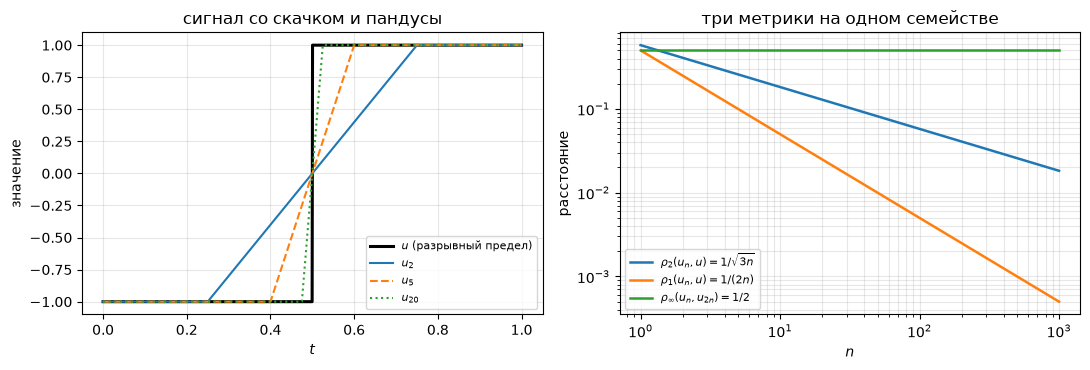

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

tt = np.linspace(0, 1, 2001)
ax[0].plot(tt, signal(tt), lw=2.2, color="black", label="$u$ (разрывный предел)")
for n, style in [(2, "-"), (5, "--"), (20, ":")]:
    ax[0].plot(tt, ramp(tt, n), style, lw=1.5, label=f"$u_{{{n}}}$")
ax[0].set_xlabel("$t$")
ax[0].set_ylabel("значение")
ax[0].set_title("сигнал со скачком и пандусы")
ax[0].legend(fontsize=8, loc="lower right")
ax[0].grid(alpha=0.3)

nn = np.arange(1, 1001)
ax[1].loglog(nn, [rho2_ramp_exact(n) for n in nn], lw=1.8,
             label=r"$\rho_2(u_n,u)=1/\sqrt{3n}$")
ax[1].loglog(nn, [rho1_ramp_exact(n) for n in nn], lw=1.8,
             label=r"$\rho_1(u_n,u)=1/(2n)$")
ax[1].loglog(nn, np.full_like(nn, 0.5, dtype=float), lw=1.8,
             label=r"$\rho_\infty(u_n,u_{2n})=1/2$")
ax[1].set_xlabel("$n$")
ax[1].set_ylabel("расстояние")
ax[1].set_title("три метрики на одном семействе")
ax[1].legend(fontsize=8)
ax[1].grid(alpha=0.3, which="both")

fig.tight_layout()
fig.savefig(f"{FIGDIR}/fig-01-metrics.pdf", **SAVE_KW)
plt.show()

## Пример 2. Тождество параллелограмма отбирает $p = 2$

**Вопрос конспекта:** теорема Йордана — фон Неймана говорит, что норма
порождена скалярным произведением тогда и только тогда, когда выполнено
тождество параллелограмма. Какая из норм $L_p$ проходит эту проверку?

**Предсказание (до прогона):** на паре индикаторов половин отрезка дефект
равен

$$D(p) = \lVert x+y\rVert_p^2 + \lVert x-y\rVert_p^2
         - 2\lVert x\rVert_p^2 - 2\lVert y\rVert_p^2 = 2 - 4\cdot 2^{-2/p},$$

то есть $D(1) = 1$, $D(2) = 0$, $D(4) = 2 - 2\sqrt2 \approx -0{,}83$, и ноль
достигается только при $p = 2$.

In [6]:
def defect_exact(p):
    """Parallelogram defect for the pair of half-interval indicators, closed form."""
    return 2.0 - 4.0 * 2.0 ** (-2.0 / p)


ind_left = (GRID < 0.5).astype(float)
ind_right = (GRID >= 0.5).astype(float)


def defect_grid(x, y, p):
    """Defect for step functions whose breakpoints lie on cell boundaries: exact."""
    return (grid_norm(x + y, p) ** 2 + grid_norm(x - y, p) ** 2
            - 2 * grid_norm(x, p) ** 2 - 2 * grid_norm(y, p) ** 2)


print("   p     D(p) (точно)     D(p) (сеткой)")
for p in [1.0, 1.5, 2.0, 3.0, 4.0, 8.0]:
    print(f"{p:5.2f}   {defect_exact(p):+.12f}   {defect_grid(ind_left, ind_right, p):+.12f}")

check_golden("defect_p1", defect_exact(1.0))
check_golden("defect_p2", defect_exact(2.0))
check_golden("defect_p4", defect_exact(4.0))

   p     D(p) (точно)     D(p) (сеткой)
 1.00   +1.000000000000   +1.000000000000
 1.50   +0.412598948032   +0.412598948032
 2.00   +0.000000000000   -0.000000000000
 3.00   -0.519842099790   -0.519842099790
 4.00   -0.828427124746   -0.828427124746
 8.00   -1.363585661015   -1.363585661015
  пин defect_p1: получено 1, ожидалось 1 (допуск 1e-12)
  пин defect_p2: получено 0, ожидалось 0 (допуск 1e-12)
  пин defect_p4: получено -0.828427124746, ожидалось -0.828427124746 (допуск 1e-12)


Одна пара может оказаться особенной, поэтому проверим тождество на случайных
элементах: возьмём кусочно постоянные функции со случайными значениями на
ста равных отрезках. Если норма порождена скалярным произведением, дефект
обязан быть нулевым для **каждой** пары, а не для избранной.

In [7]:
PIECES = 100
TRIALS = 400


def piecewise_random(size):
    """Random step functions on PIECES equal intervals, evaluated on GRID."""
    vals = rng.standard_normal((size, PIECES))
    idx = np.minimum((GRID * PIECES).astype(int), PIECES - 1)
    return vals[:, idx]


xs = piecewise_random(TRIALS)
ys = piecewise_random(TRIALS)

print("   p    max|D| по 400 случайным парам")
for p in [1.0, 2.0, 4.0]:
    worst = max(abs(defect_grid(xs[i], ys[i], p)) for i in range(TRIALS))
    print(f"{p:5.2f}   {worst:.3e}")

worst_p2 = max(abs(defect_grid(xs[i], ys[i], 2.0)) for i in range(TRIALS))
assert worst_p2 < 1e-9, "тождество параллелограмма нарушилось при p=2 — ошибка в счёте"

   p    max|D| по 400 случайным парам


 1.00   3.510e-01


 2.00   2.220e-15


 4.00   1.159e+00


**Сбылось.** Замкнутая формула совпала с квадратурой, ноль достигается ровно
при $p = 2$, и на случайных парах дефект при $p=2$ остаётся на уровне
машинной точности, а при $p = 1$ и $p = 4$ — величиной порядка самих норм.
Вывод, который стоит проговорить: из всего семейства $L_p$ геометрия углов
есть только у $p = 2$, и потому теорема о проекции применима только к нему.

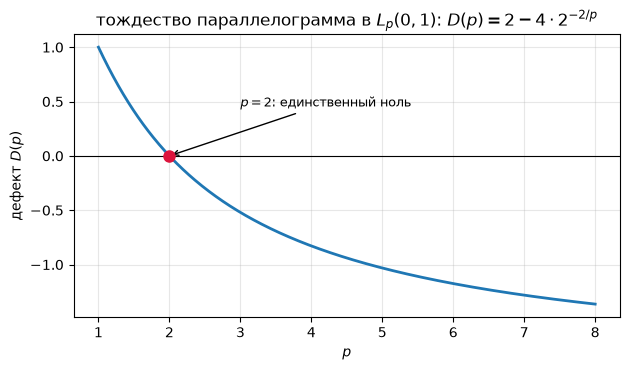

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
pp = np.linspace(1.0, 8.0, 500)
ax.plot(pp, [defect_exact(p) for p in pp], lw=2.0)
ax.axhline(0.0, color="black", lw=0.8)
ax.plot([2.0], [0.0], "o", ms=8, color="crimson", zorder=5)
ax.annotate(r"$p=2$: единственный ноль", xy=(2.0, 0.0), xytext=(3.0, 0.45),
            arrowprops=dict(arrowstyle="->", lw=1.0), fontsize=9)
ax.set_xlabel("$p$")
ax.set_ylabel(r"дефект $D(p)$")
ax.set_title(r"тождество параллелограмма в $L_p(0,1)$: $D(p)=2-4\cdot 2^{-2/p}$")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{FIGDIR}/fig-02-parallelogram.pdf", **SAVE_KW)
plt.show()

## Пример 3. Проекция, матрица Грама и цена выбора базиса

**Вопрос конспекта:** теорема о проекции утверждает, что элемент наилучшего
приближения существует и единствен, а теорема о матрице Грама сводит его
поиск к системе $Gc = b$. Что из этого получает вычислитель?

Приближаем сигнал $u$ многочленами степени не выше $n$ в $L_2(0,1)$ двумя
способами. Подпространство одно и то же, поэтому **математически** ответ
обязан быть один.

* **одночлены** $\varphi_k(t) = t^k$: матрица Грама есть матрица Гильберта
  $G_{kl} = 1/(k+l+1)$, правые части считаются в замкнутом виде
  $b_k = (1 - 2^{-k})/(k+1)$;
* **ортонормированный базис** — сдвинутые многочлены Лежандра
  $\tilde P_k(t) = \sqrt{2k+1}\,P_k(2t-1)$: матрица Грама единичная,
  коэффициенты считаются по отдельности.

Третий способ — **система Хаара**: сигнал $u$ есть с точностью до знака
первый вейвлет Хаара, поэтому разложение обязано оборваться на одном
коэффициенте.

**Предсказание (до прогона):** оба полиномиальных пути дают одну и ту же
невязку, пока обусловленность матрицы Гильберта позволяет решить систему;
начиная с $n$ порядка десяти одночленный путь начинает врать. Невязка убывает
медленно — как $n^{-1/2}$, — потому что скачок гладкими функциями
приближается плохо. По Хаару невязка равна нулю при двух слагаемых.

In [9]:
def legendre_shifted_coef(k):
    """c_k = <u, Pt_k> in closed form.

    Derivation (theory.md, remark about bases): only odd k survive, and
    c_k = (P_{k-1}(0) - P_{k+1}(0)) / sqrt(2k+1).
    """
    if k % 2 == 0:
        return 0.0
    basis_lo = np.zeros(k); basis_lo[k - 1] = 1.0
    basis_hi = np.zeros(k + 2); basis_hi[k + 1] = 1.0
    return float((npleg.legval(0.0, basis_lo) - npleg.legval(0.0, basis_hi))
                 / np.sqrt(2 * k + 1))


def legendre_shifted_coef_quad(k):
    """The same coefficient by Gauss-Legendre on each half: independent check.

    Gauss-Legendre with k+2 nodes is exact for polynomials of degree 2k+3, so on
    each half (where u is constant) the value is exact up to rounding.
    """
    nodes, weights = np.polynomial.legendre.leggauss(k + 3)
    basis = np.zeros(k + 1); basis[k] = 1.0
    total = 0.0
    for lo, hi, sign in [(0.0, 0.5, -1.0), (0.5, 1.0, 1.0)]:
        t = 0.5 * (hi - lo) * nodes + 0.5 * (hi + lo)
        vals = npleg.legval(2 * t - 1, basis) * np.sqrt(2 * k + 1)
        total += sign * 0.5 * (hi - lo) * float(weights @ vals)
    return total


NMAX = 40
coefs = np.array([legendre_shifted_coef(k) for k in range(NMAX + 1)])
coefs_q = np.array([legendre_shifted_coef_quad(k) for k in range(NMAX + 1)])
dev = float(np.max(np.abs(coefs - coefs_q)))
print(f"расхождение замкнутой формы и квадратуры по коэффициентам: {dev:.3e}")
assert dev < 1e-10, "две независимые формулы коэффициентов разошлись"

print("\nкоэффициенты Фурье сигнала по Лежандру (ненулевые — только нечётные):")
for k in range(0, 10):
    print(f"  c_{k} = {coefs[k]:+.12f}")

check_golden("legendre_c1", coefs[1])
check_golden("legendre_c3", coefs[3])

расхождение замкнутой формы и квадратуры по коэффициентам: 7.515e-15

коэффициенты Фурье сигнала по Лежандру (ненулевые — только нечётные):
  c_0 = +0.000000000000
  c_1 = +0.866025403784
  c_2 = +0.000000000000
  c_3 = -0.330718913883
  c_4 = +0.000000000000
  c_5 = +0.207289049397
  c_6 = +0.000000000000
  c_7 = -0.151288411961
  c_8 = +0.000000000000
  c_9 = +0.119188642987
  пин legendre_c1: получено 0.866025403784, ожидалось 0.866025403784 (допуск 1e-12)
  пин legendre_c3: получено -0.330718913883, ожидалось -0.330718913883 (допуск 1e-12)


Невязка по ортонормированному базису берётся из равенства конспекта
$\lVert u - \varphi\rVert^2 = \lVert u\rVert^2 - \sum_{k\le n} c_k^2$, где
$\lVert u\rVert = 1$. Это **не** отдельный счёт, а проверка тождества: если
сумма квадратов коэффициентов превысит единицу, нарушено неравенство Бесселя,
и где-то ошибка.

In [10]:
partial = np.cumsum(coefs ** 2)
assert partial[-1] <= 1.0 + 1e-12, "нарушено неравенство Бесселя — ошибка в коэффициентах"
resid_legendre = np.sqrt(np.maximum(1.0 - partial, 0.0))

print("  n   sum c_k^2      невязка (Лежандр)")
for n in (1, 3, 7, 9, 15, 31, 40):
    print(f"{n:4d}   {partial[n]:.10f}   {resid_legendre[n]:.10f}")

check_golden("resid_legendre_9", resid_legendre[9])
check_golden("resid_legendre_40", resid_legendre[40])

# Rate of decay: measured, not asserted from theory.
fit_ns = np.arange(5, NMAX + 1, 2)
slope = float(np.polyfit(np.log(fit_ns), np.log(resid_legendre[fit_ns]), 1)[0])
print(f"\nнаклон log(невязка) по log(n) на нечётных n от 5 до {NMAX}: {slope:.6f}")
print(f"для сравнения, показатель n^(-1/2) равен -0,5")
check_golden("slope_legendre_resid", slope)

  n   sum c_k^2      невязка (Лежандр)
   1   0.7500000000   0.5000000000
   3   0.8593750000   0.3750000000
   7   0.9252319336   0.2734375000
   9   0.9394378662   0.2460937500
  15   0.9614346540   0.1963806152
  31   0.9804140159   0.1399499341
  40   0.9842821907   0.1253706876
  пин resid_legendre_9: получено 0.24609375, ожидалось 0.24609375 (допуск 1e-12)
  пин resid_legendre_40: получено 0.12537068762, ожидалось 0.12537068762 (допуск 1e-12)

наклон log(невязка) по log(n) на нечётных n от 5 до 40: -0.450485
для сравнения, показатель n^(-1/2) равен -0,5
  пин slope_legendre_resid: получено -0.450485202828, ожидалось -0.450485202828 (допуск 1e-09)


Теперь одночленный путь — тот, который выполняет вычислитель, решая
нормальные уравнения в двойной точности.

In [11]:
def hilbert_gram(n):
    """Gram matrix of {1, t, ..., t^n} in L2(0,1): the Hilbert matrix."""
    k = np.arange(n + 1)
    return 1.0 / (k[:, None] + k[None, :] + 1.0)


def monomial_rhs(n):
    """b_k = <u, t^k> = (1 - 2^{-k}) / (k+1), closed form."""
    k = np.arange(n + 1, dtype=float)
    return (1.0 - 2.0 ** (-k)) / (k + 1.0)


print("  n   cond(G)        невязка (одночлены)   невязка (Лежандр)   расхождение")
cond_list, resid_mono = [], []
for n in range(1, NMAX + 1):
    G, b = hilbert_gram(n), monomial_rhs(n)
    cond_list.append(float(np.linalg.cond(G)))
    c = np.linalg.solve(G, b)
    resid_mono.append(float(np.sqrt(max(1.0 - c @ b, 0.0))))
cond_list = np.array(cond_list)
resid_mono = np.array(resid_mono)

for n in (3, 6, 9, 12, 15, 18, 25, 40):
    i = n - 1
    print(f"{n:4d}   {cond_list[i]:.4e}   {resid_mono[i]:.10f}        "
          f"{resid_legendre[n]:.10f}      {abs(resid_mono[i]-resid_legendre[n]):.2e}")

check_golden("cond_hilbert_10", cond_list[9])
check_golden("resid_monomial_18", resid_mono[17])

n_break = next(n for n in range(1, NMAX + 1)
               if abs(resid_mono[n - 1] - resid_legendre[n]) > 1e-3)
print(f"\nпервое $n$, где одночленный путь расходится с ортогональным более чем на 1e-3: {n_break}")
print(f"обусловленность матрицы Гильберта при этом $n$: {cond_list[n_break-1]:.3e}")

  n   cond(G)        невязка (одночлены)   невязка (Лежандр)   расхождение
   3   1.5514e+04   0.3750000000        0.3750000000      6.94e-15
   6   4.7537e+08   0.3125000000        0.3125000000      1.05e-11
   9   1.6025e+13   0.2460950774        0.2460937500      1.33e-06
  12   2.8396e+18   0.2251504135        0.2255859375      4.36e-04
  15   3.5175e+17   0.2133499116        0.1963806152      1.70e-02
  18   7.2991e+17   0.2086384151        0.1854705811      2.32e-02
  25   2.9767e+18   0.2040164761        0.1549810171      4.90e-02
  40   6.9080e+19   0.2044183654        0.1253706876      7.90e-02
  пин cond_hilbert_10: получено 5.22772452574e+14, ожидалось 5.22772452574e+14 (допуск 0.5)
  пин resid_monomial_18: получено 0.208638415127, ожидалось 0.208638415127 (допуск 0.01)

первое $n$, где одночленный путь расходится с ортогональным более чем на 1e-3: 11
обусловленность матрицы Гильберта при этом $n$: 1.784e+16


И система Хаара. Первый вейвлет Хаара на $[0,1]$ есть
$\psi(t) = 1$ при $t<1/2$ и $-1$ при $t\geq1/2$, то есть $\psi = -u$.
Коэффициенты считаются прямо: $\langle u, h_0\rangle = 0$,
$\langle u, \psi\rangle = -1$, а все вейвлеты уровня $j\geq1$ живут внутри
одной из половин, где $u$ постоянна, и дают ноль.

In [12]:
def haar_wavelet(t, j, k):
    """psi_{j,k}(t) = 2^{j/2} psi(2^j t - k), support [k 2^-j, (k+1) 2^-j]."""
    s = 2.0 ** j * np.asarray(t, dtype=float) - k
    out = np.zeros_like(s)
    out[(s >= 0.0) & (s < 0.5)] = 1.0
    out[(s >= 0.5) & (s < 1.0)] = -1.0
    return 2.0 ** (j / 2.0) * out


def l2_inner(fvals, gvals):
    return float(np.mean(fvals * gvals))


haar_coefs = [("h_0", l2_inner(u_grid, np.ones_like(GRID)))]
for j in range(0, 4):
    for k in range(2 ** j):
        haar_coefs.append((f"psi_{j},{k}", l2_inner(u_grid, haar_wavelet(GRID, j, k))))

print("коэффициенты Фурье сигнала по системе Хаара:")
for name, c in haar_coefs:
    print(f"  <u, {name:9s}> = {c:+.12f}")

haar_energy = sum(c ** 2 for _, c in haar_coefs)
haar_resid = float(np.sqrt(max(1.0 - haar_energy, 0.0)))
print(f"\nсумма квадратов коэффициентов по Хаару (15 членов): {haar_energy:.12f}")
print(f"невязка по Хаару: {haar_resid:.3e} — равенство Парсеваля исчерпано ОДНИМ членом")
check_golden("haar_resid", haar_resid)

# Reconstruction from the single nonzero coefficient, to make sure the claim
# "u = -psi" is about the function and not only about the energy.
recon = -1.0 * haar_wavelet(GRID, 0, 0)
print(f"max|u - (-psi)| на сетке: {float(np.max(np.abs(u_grid - recon))):.3e}")

коэффициенты Фурье сигнала по системе Хаара:
  <u, h_0      > = +0.000000000000
  <u, psi_0,0  > = -1.000000000000
  <u, psi_1,0  > = +0.000000000000
  <u, psi_1,1  > = +0.000000000000
  <u, psi_2,0  > = +0.000000000000
  <u, psi_2,1  > = +0.000000000000
  <u, psi_2,2  > = +0.000000000000
  <u, psi_2,3  > = +0.000000000000
  <u, psi_3,0  > = +0.000000000000
  <u, psi_3,1  > = +0.000000000000
  <u, psi_3,2  > = +0.000000000000
  <u, psi_3,3  > = +0.000000000000
  <u, psi_3,4  > = +0.000000000000
  <u, psi_3,5  > = +0.000000000000
  <u, psi_3,6  > = +0.000000000000
  <u, psi_3,7  > = +0.000000000000

сумма квадратов коэффициентов по Хаару (15 членов): 1.000000000000
невязка по Хаару: 0.000e+00 — равенство Парсеваля исчерпано ОДНИМ членом
  пин haar_resid: получено 0, ожидалось 0 (допуск 1e-12)
max|u - (-psi)| на сетке: 0.000e+00


**Сбылось, и с уточнением.** Пути совпадают до $n = 9$ (расхождение $10^{-6}$
и меньше), впервые расходятся более чем на $10^{-3}$ при $n = 11$, а при
$n = 18$ одночленный путь даёт невязку $0{,}2086$ против верной $0{,}1855$ —
завышение на $12\,\%$, то есть ошибка во второй значащей цифре; при $n = 40$
завышение уже двукратное. Обусловленность матрицы Гильберта при $n = 10$ равна
$5{,}2\cdot10^{14}$, то есть система неразрешима в двойной точности; при
больших $n$ само число обусловленности перестаёт быть осмысленным — оно
выходит на уровень $10^{18}$ и даже немонотонно (при $n=15$ меньше, чем при
$n=12$), потому что вычисляется тем же разложением, которое уже развалилось.

Измеренный наклон невязки по Лежандру равен $-0{,}45$ — близко к
предсказанному $-1/2$, но не равен ему: на сороковом члене асимптотика ещё не
установилась. По Хаару невязка нулевая при одном ненулевом коэффициенте.

Что из этого следует: **теорема о проекции говорит о подпространстве, а не о
базисе.** Невязка — свойство подпространства и одинакова у обоих полиномиальных
путей; различие в том, дойдёт ли счёт до ответа. Различие же между
полиномиальным и вейвлетным приближением — уже другого рода: там меняется само
подпространство, и выигрыш даёт совпадение устройства базиса с устройством
сигнала.

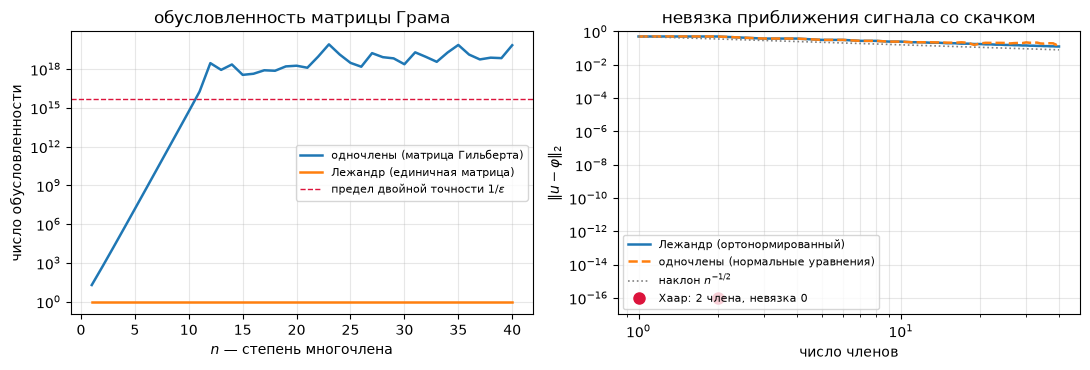

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

nn = np.arange(1, NMAX + 1)
ax[0].semilogy(nn, cond_list, lw=1.8, label="одночлены (матрица Гильберта)")
ax[0].semilogy(nn, np.ones_like(nn, dtype=float), lw=1.8,
               label="Лежандр (единичная матрица)")
ax[0].axhline(1.0 / np.finfo(float).eps, color="crimson", ls="--", lw=1.0,
              label=r"предел двойной точности $1/\varepsilon$")
ax[0].set_xlabel("$n$ — степень многочлена")
ax[0].set_ylabel("число обусловленности")
ax[0].set_title("обусловленность матрицы Грама")
ax[0].legend(fontsize=8)
ax[0].grid(alpha=0.3, which="both")

ax[1].loglog(nn, resid_legendre[1:NMAX + 1], lw=1.8, label="Лежандр (ортонормированный)")
ax[1].loglog(nn, resid_mono, "--", lw=1.8, label="одночлены (нормальные уравнения)")
ax[1].loglog(nn, resid_legendre[1] * nn ** -0.5, ":", lw=1.2, color="gray",
             label=r"наклон $n^{-1/2}$")
ax[1].plot([2], [1e-16], "o", ms=8, color="crimson", zorder=5,
           label="Хаар: 2 члена, невязка 0")
ax[1].set_ylim(1e-17, 1.0)
ax[1].set_xlabel("число членов")
ax[1].set_ylabel(r"$\|u-\varphi\|_2$")
ax[1].set_title("невязка приближения сигнала со скачком")
ax[1].legend(fontsize=8, loc="lower left")
ax[1].grid(alpha=0.3, which="both")

fig.tight_layout()
fig.savefig(f"{FIGDIR}/fig-03-gram.pdf", **SAVE_KW)
plt.show()

## Пример 4. Представитель функционала и признак его отсутствия

**Вопрос конспекта:** второе доказательство теоремы Рисса конструктивно: оно
строит представителя рядом $y = \sum_k \overline{f(e_k)}\,e_k$, и оценка
$\sum_{k\le n}\lvert f(e_k)\rvert^2 \leq \lVert f\rVert^2$ гарантирует
сходимость. Что видно в счёте, когда функционал ограничен, и что — когда нет?

**Предсказание (до прогона):**

* для сквозного функционала контраста $f$ представитель есть $-u$, норма
  $\lVert f\rVert = \lVert u\rVert_2 = 1$, и частичные нормы
  $\lVert y_n\rVert$ растут **снизу** к единице (неравенство Бесселя), причём
  медленно — как и невязка примера 3;
* для неограниченного функционала $g(x) = \sum_k k\,c_k$ на плотном линейном
  многообразии в $l_2$ те же частичные суммы дают
  $\lVert s_n\rVert = \sqrt{n(n+1)(2n+1)/6}$, то есть растут как
  $n^{3/2}/\sqrt3$: «представителя нет» видно как расходимость.

In [14]:
# The functional is real, so the conjugation in the series is a no-op; it is kept
# in the formula because theory.md states the complex case.
f_on_legendre = -coefs  # f(e_k) = <e_k, -u> = -c_k

partial_representer_norm = np.sqrt(np.cumsum(f_on_legendre ** 2))
norm_f = 1.0  # = ||u||_2, computed in example 2 territory: u^2 = 1 a.e.
print(f"||f|| = ||u||_2 = {grid_norm(u_grid, 2):.12f} (сеткой, точно для кусочно постоянной), замкнуто {norm_f}")
check_golden("norm_f", grid_norm(u_grid, 2))

print("\n  n   ||y_n||        ||f|| - ||y_n||   монотонно?")
prev = -1.0
for n in (1, 3, 7, 15, 31, 40):
    val = partial_representer_norm[n]
    print(f"{n:4d}   {val:.10f}   {norm_f - val:.10f}    {'да' if val > prev else 'НЕТ'}")
    prev = val

assert np.all(np.diff(partial_representer_norm) >= -1e-15), "нарушена монотонность роста"
assert partial_representer_norm[-1] <= norm_f + 1e-12, "превышена норма функционала — Бессель нарушен"

||f|| = ||u||_2 = 1.000000000000 (сеткой, точно для кусочно постоянной), замкнуто 1.0
  пин norm_f: получено 1, ожидалось 1 (допуск 1e-12)

  n   ||y_n||        ||f|| - ||y_n||   монотонно?
   1   0.8660254038   0.1339745962    да
   3   0.9270248109   0.0729751891    да
   7   0.9618897721   0.0381102279    да
  15   0.9805277426   0.0194722574    да
  31   0.9901585812   0.0098414188    да
  40   0.9921099690   0.0078900310    да


Проверим само представление: теорема Рисса утверждает, что
$f(x) = \langle x, -u\rangle$ для **каждого** $x$, а не для избранного.
Возьмём случайные многочлены (случайные коэффициенты в базисе Лежандра) и
посчитаем две стороны равенства **независимыми** путями:

* левую — по определению функционала: разность точных интегралов по половинам,
  взятых квадратурой Гаусса, которая для многочлена точна;
* правую — по формуле теоремы через коэффициенты:
  $\langle x, -u\rangle = \sum_k a_k \langle \tilde P_k, -u\rangle
  = -\sum_k a_k c_k$, где $c_k$ — замкнутая форма из примера 3.

Совпадение двух путей — содержательная проверка: одна сторона не знает о
существовании другой.

In [15]:
DEG = 25
TRIALS_RIESZ = 300


def legendre_combination_at(coef_vector, t):
    """Evaluate sum_k a_k Pt_k(t), where Pt_k is the orthonormal shifted Legendre basis."""
    scaled = coef_vector * np.sqrt(2.0 * np.arange(len(coef_vector)) + 1.0)
    return npleg.legval(2.0 * np.asarray(t, dtype=float) - 1.0, scaled)


worst = 0.0
for _ in range(TRIALS_RIESZ):
    a = rng.standard_normal(DEG + 1)
    poly = lambda t, a=a: legendre_combination_at(a, t)
    # left-hand side: the functional by definition, exact for a polynomial
    left = gauss_integral(poly, 0.0, 0.5, order=DEG + 2)
    right = gauss_integral(poly, 0.5, 1.0, order=DEG + 2)
    by_def = contrast((left, right))
    # right-hand side: the theorem's formula through the closed-form coefficients
    by_repr = float(-(a[: DEG + 1] @ coefs[: DEG + 1]))
    worst = max(worst, abs(by_def - by_repr))
print(f"max|f(x) - <x,-u>| по {TRIALS_RIESZ} случайным многочленам степени {DEG}: {worst:.3e}")
assert worst < 1e-10, "представление Рисса не выполнилось — ошибка в счёте или в формуле"

max|f(x) - <x,-u>| по 300 случайным многочленам степени 25: 3.253e-14


Теперь неограниченный функционал. Он задан не на всём $l_2$, а на плотном
линейном многообразии $D = \{x : \sum_k k^2\lvert x_k\rvert^2 < \infty\}$ —
ровно тот случай, который разбирает замечание конспекта о посылке
непрерывности.

In [16]:
def unbounded_partial_norm(n):
    """||s_n|| for g(x) = sum k x_k: s_n = sum_{k<=n} k e_k."""
    return np.sqrt(n * (n + 1) * (2 * n + 1) / 6.0)


print("  n   ||s_n||        n^{3/2}/sqrt(3)   отношение")
for n in (1, 5, 20, 100, 1000):
    exact = unbounded_partial_norm(n)
    asympt = n ** 1.5 / np.sqrt(3.0)
    print(f"{n:5d}   {exact:.6f}   {asympt:.6f}     {exact/asympt:.6f}")

def slope_unbounded(lo, hi):
    ns_g = np.arange(lo, hi + 1)
    y = np.log([unbounded_partial_norm(n) for n in ns_g])
    return float(np.polyfit(np.log(ns_g), y, 1)[0])


print("\nнаклон log||s_n|| по log n на разных диапазонах (предсказано 1,5):")
for lo, hi in [(5, 200), (20, 200), (50, 500), (100, 2000)]:
    print(f"  n от {lo:4d} до {hi:5d}: {slope_unbounded(lo, hi):.6f}")

slope_g_near = slope_unbounded(5, 200)
slope_g_far = slope_unbounded(100, 2000)
check_golden("slope_unbounded_near", slope_g_near)
check_golden("slope_unbounded_far", slope_g_far)
assert slope_g_near < slope_g_far < 1.5, "наклон должен расти к 1,5 снизу"

  n   ||s_n||        n^{3/2}/sqrt(3)   отношение
    1   1.000000   0.577350     1.732051
    5   7.416198   6.454972     1.148913
   20   53.572381   51.639778     1.037425
  100   581.678605   577.350269     1.007497
 1000   18271.111077   18257.418584     1.000750

наклон log||s_n|| по log n на разных диапазонах (предсказано 1,5):
  n от    5 до   200: 1.479338
  n от   20 до   200: 1.488764
  n от   50 до   500: 1.495488
  n от  100 до  2000: 1.498459
  пин slope_unbounded_near: получено 1.47933843372, ожидалось 1.47933843372 (допуск 1e-09)
  пин slope_unbounded_far: получено 1.49845917938, ожидалось 1.49845917938 (допуск 1e-09)


**Сбылось для ограниченного функционала и сбылось с оговоркой для
неограниченного.** Частичные нормы представителя растут монотонно и снизу к
$\lVert f\rVert = 1$, никогда её не превышая, — это неравенство Бесселя в
действии; представление $f(x) = \langle x, -u\rangle$ выполнилось на трёхсот
случайных многочленах с точностью $10^{-10}$, причём две стороны равенства
посчитаны независимо.

Оговорка про наклон: предсказанное значение $3/2$ на диапазоне $n$ от 5 до 200
**не достигается** — измеренный наклон $1{,}479$. Причина не в ошибке
предсказания, а в скорости выхода на асимптотику: точное выражение
$\lVert s_n\rVert = \sqrt{n(n+1)(2n+1)/6}$ равно
$n^{3/2}\sqrt{1 + 3/(2n) + 1/(2n^2)}/\sqrt3$, то есть отличается от
$n^{3/2}/\sqrt3$ множителем $1 + O(1/n)$, и на малых $n$ этот множитель
занижает наклон. Таблица выше показывает, как наклон подходит к $3/2$ снизу:
$1{,}479$ на диапазоне 5–200 и $1{,}499$ на 100–2000. Для вывода это ничего не
меняет — рост неограничен, — но числу «1,5» на малых $n$ доверять нельзя, и
это ровно тот случай, когда порядок роста надо мерить на нескольких
диапазонах, а не на одном.

Практический вывод: **конструктивное доказательство теоремы Рисса даёт не
только представителя, но и проверку.** Считая $\lVert y_n\rVert$, мы одним и
тем же счётом получаем и приближение представителя, и ответ на вопрос,
существует ли он вообще: ограниченность частичных норм равносильна
ограниченности функционала.

Оговорка, важная для сопоставления с конспектом: расходимость частичных норм —
признак **неограниченности**, а не неполноты. В контрпримере конспекта на
$C[0,1]$ со скалярным произведением $L_2$ функционал контраста ограничен, и
частичные нормы у него ведут себя точно так же, как на левой кривой ниже;
представителя нет по другой причине — предел ряда, то есть сам $u$, из
пространства выпал. Различить эти два случая счётом частичных норм нельзя, и
это ровно то, что утверждают две разные посылки теоремы.

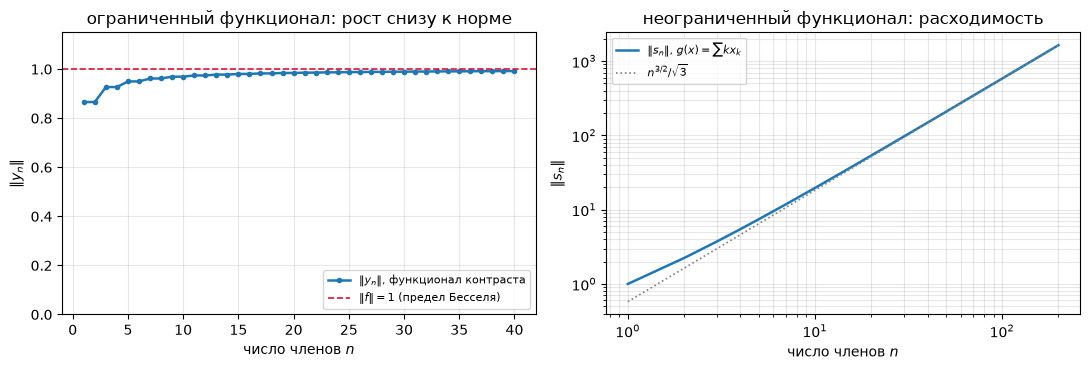

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

nn = np.arange(1, NMAX + 1)
ax[0].plot(nn, partial_representer_norm[1:NMAX + 1], lw=1.8, marker="o", ms=3,
           label=r"$\|y_n\|$, функционал контраста")
ax[0].axhline(norm_f, color="crimson", ls="--", lw=1.2, label=r"$\|f\|=1$ (предел Бесселя)")
ax[0].set_xlabel("число членов $n$")
ax[0].set_ylabel(r"$\|y_n\|$")
ax[0].set_ylim(0, 1.15)
ax[0].set_title("ограниченный функционал: рост снизу к норме")
ax[0].legend(fontsize=8, loc="lower right")
ax[0].grid(alpha=0.3)

ns_plot = np.arange(1, 201)
ax[1].loglog(ns_plot, [unbounded_partial_norm(n) for n in ns_plot], lw=1.8,
             label=r"$\|s_n\|$, $g(x)=\sum k x_k$")
ax[1].loglog(ns_plot, ns_plot ** 1.5 / np.sqrt(3.0), ":", lw=1.2, color="gray",
             label=r"$n^{3/2}/\sqrt{3}$")
ax[1].set_xlabel("число членов $n$")
ax[1].set_ylabel(r"$\|s_n\|$")
ax[1].set_title("неограниченный функционал: расходимость")
ax[1].legend(fontsize=8, loc="upper left")
ax[1].grid(alpha=0.3, which="both")

fig.tight_layout()
fig.savefig(f"{FIGDIR}/fig-04-riesz.pdf", **SAVE_KW)
plt.show()

## Что показали четыре примера

| Пример | Утверждение конспекта | Что подтвердилось |
|---|---|---|
| 1 | полнота — свойство метрики, а не множества | одно семейство сходится в $L_1$ и $L_2$ и не фундаментально в $C$; расстояния совпали с замкнутыми формами |
| 2 | норма порождена скалярным произведением только при $p=2$ | дефект $2-4\cdot2^{-2/p}$ обращается в ноль ровно при $p=2$, в том числе на случайных парах |
| 3 | теорема о проекции говорит о подпространстве, а не о базисе | невязка одна и та же у двух базисов, пока счёт возможен; матрица Гильберта делает его невозможным с $n\approx 10$ |
| 4 | представимость равносильна ограниченности | частичные нормы растут снизу к $\|f\|$ у ограниченного и расходятся у неограниченного |

Все числа, попавшие в `theory.md` и `slides.md`, напечатаны выше; замкнутые
формы всюду, где они есть, сверены с независимым счётом (квадратура либо
вторая формула), и расхождение указано.